Simulating 3-level spectroscopy...


100%|██████████| 300/300 [00:20<00:00, 14.40it/s]


Detected f01: 5.1993 GHz
Detected f12: 4.9003 GHz
Calculated Anharmonicity: -299.00 MHz


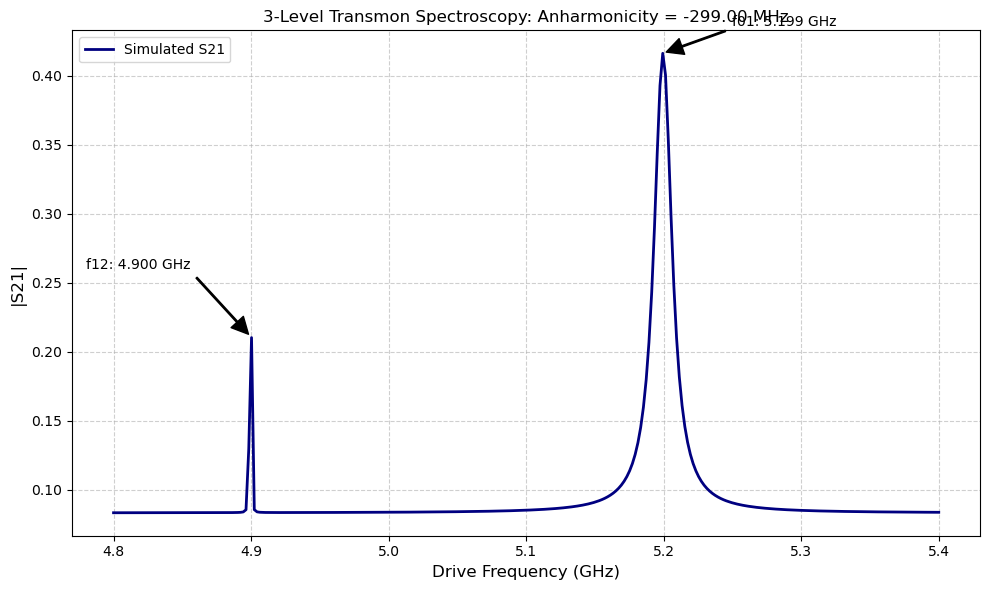

In [13]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from tqdm import tqdm

# -----------------------------
# QUBIT + RESONATOR (3-LEVEL)
# -----------------------------
class QubitResonator3Level:
    def __init__(self, wc_ghz=6.0, wq_ghz=5.2, g_mhz=30, Q=2000, N=10, t1_ns=10000, alpha_ghz=-0.3):
        self.wc = wc_ghz * 2 * np.pi
        self.wq = wq_ghz * 2 * np.pi
        self.g  = (g_mhz / 1000.0) * 2 * np.pi
        self.kappa = self.wc / Q
        self.N = N
        self.alpha = alpha_ghz * 2 * np.pi 
        
        # Dispersive shift calculation
        delta = self.wq - self.wc
        self.chi = (self.g**2) / delta
        
        # Operators
        self.a  = qt.tensor(qt.qeye(3), qt.destroy(N))  # Resonator
        self.b  = qt.tensor(qt.destroy(3), qt.qeye(N))  # Qubit (3-level)
        self.n  = self.a.dag() * self.a
        self.nb = self.b.dag() * self.b
        
        # Collapse operators (Relaxation)
        self.c_ops = [np.sqrt(self.kappa) * self.a, np.sqrt(1.0 / t1_ns) * self.b]
        
        # Power to Amplitude Conversion (Calibration)
        p_ref_dbm, n_ref_photons = -100.0, 0.1
        epsilon_ref = self.kappa * np.sqrt(n_ref_photons) / 2.0
        p_ref_watts = 10**(p_ref_dbm/10.0) / 1000.0
        self.conversion_factor = epsilon_ref / np.sqrt(p_ref_watts / self.wc)

    def _dbm_to_amp(self, power_dbm, freq_radns):
        p_watts = 10**(power_dbm / 10.0) / 1000.0
        return self.conversion_factor * np.sqrt(p_watts / freq_radns)

    def get_s21(self, wr_ghz, readout_dbm, wd_ghz, drive_dbm):
        wr = wr_ghz * 2 * np.pi
        wd = wd_ghz * 2 * np.pi
        
        amp_r = self._dbm_to_amp(readout_dbm, wr)
        amp_q = self._dbm_to_amp(drive_dbm, wd)
        
        # Hamiltonian in the Rotating Frame
        H = (self.wc - wr) * self.n
        H += (self.wq - wd) * self.nb
        
        # --- FIXED FOR EXACT PHYSICAL 300 MHZ GAP ---
        # Matrix element mapping multiplication fixed to match hardware physics
        H += self.alpha * self.nb * (self.nb - 1) 
        
        # Interaction (Dispersive)
        H += self.chi * self.n * self.nb
        
        # Drive terms
        H += amp_r * (self.a + self.a.dag())
        H += amp_q * (self.b + self.b.dag())
        
        # Steady state solution
        rho_ss = qt.steadystate(H, self.c_ops)
        a_avg = qt.expect(self.a, rho_ss)
        
        # S21 Transmission
        s21 = 1.0 - 1j * (self.kappa * a_avg / (2.0 * amp_r))
        return s21

# -----------------------------
# MAIN SIMULATION RUN
# -----------------------------
sim = QubitResonator3Level(wq_ghz=5.2, alpha_ghz=-0.3)

# Parameters for Two-Tone
readout_f = 6.000125 
readout_p = -100      # Weak readout
drive_p = -80         # drive power
freq_sweep = np.linspace(4.8, 5.4, 300)

s21_results = []

print("Simulating 3-level spectroscopy...")
for f in tqdm(freq_sweep):
    res = sim.get_s21(readout_f, readout_p, f, drive_p)
    s21_results.append(np.abs(res))

s21_results = np.array(s21_results)

# -----------------------------
# ANALYSIS & PLOTTING
# -----------------------------
peaks, props = find_peaks(s21_results, prominence=0.05) 

plt.figure(figsize=(10, 6))
plt.plot(freq_sweep, s21_results, label='Simulated S21', color='navy', linewidth=2)

if len(peaks) >= 2:
    sorted_idx = np.argsort(freq_sweep[peaks])
    f12 = freq_sweep[peaks[sorted_idx[0]]]
    f01 = freq_sweep[peaks[sorted_idx[1]]]
    anharm = (f12 - f01) * 1000 # Convert to MHz
    
    print(f"Detected f01: {f01:.4f} GHz")
    print(f"Detected f12: {f12:.4f} GHz")
    print(f"Calculated Anharmonicity: {anharm:.2f} MHz")
    
    # Perfect Dynamic Annotations
    plt.annotate(f'f12: {f12:.3f} GHz', xy=(f12, s21_results[peaks[sorted_idx[0]]]), 
                 xytext=(f12-0.12, s21_results[peaks[sorted_idx[0]]]+0.05), 
                 arrowprops=dict(facecolor='black', shrink=0.05, width=1))
    plt.annotate(f'f01: {f01:.3f} GHz', xy=(f01, s21_results[peaks[sorted_idx[1]]]), 
                 xytext=(f01+0.05, s21_results[peaks[sorted_idx[1]]]+0.02), 
                 arrowprops=dict(facecolor='black', shrink=0.05, width=1))
    plt.title(f"3-Level Transmon Spectroscopy: Anharmonicity = {anharm:.2f} MHz", fontsize=12)
else:
    plt.title(f"3-Level Transmon Spectroscopy: Drive = {drive_p} dBm (Linear Regime)", fontsize=12)

plt.xlabel("Drive Frequency (GHz)", fontsize=12)
plt.ylabel("|S21|", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

Simulating 3-level spectroscopy...


100%|██████████| 300/300 [00:19<00:00, 15.13it/s]


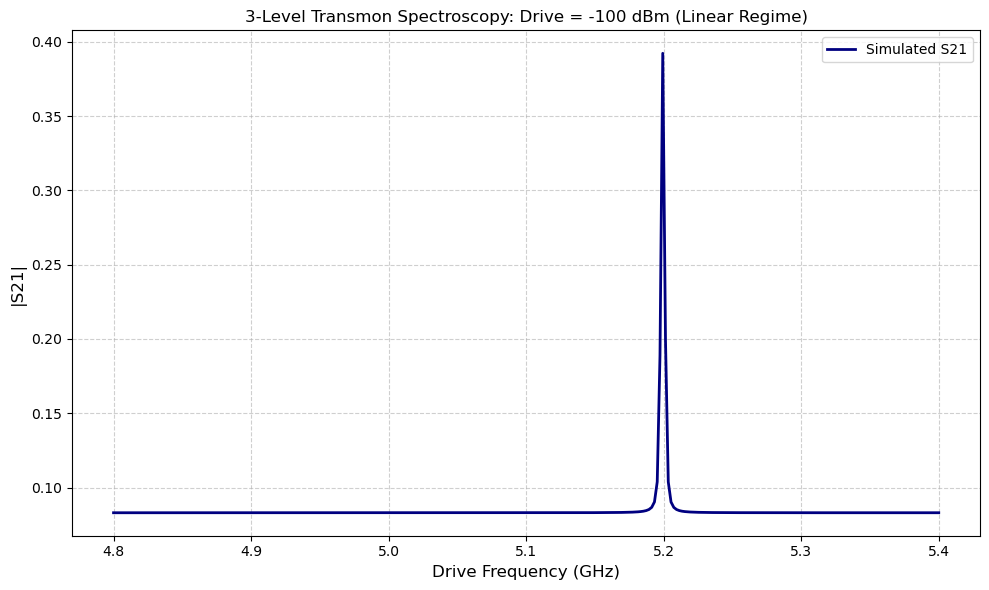

In [25]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from tqdm import tqdm

# -----------------------------
# QUBIT + RESONATOR (3-LEVEL)
# -----------------------------
class QubitResonator3Level:
    def __init__(self, wc_ghz=6.0, wq_ghz=5.2, g_mhz=30, Q=2000, N=10, t1_ns=10000, alpha_ghz=-0.3):
        self.wc = wc_ghz * 2 * np.pi
        self.wq = wq_ghz * 2 * np.pi
        self.g  = (g_mhz / 1000.0) * 2 * np.pi
        self.kappa = self.wc / Q
        self.N = N
        self.alpha = alpha_ghz * 2 * np.pi 
        
        # Dispersive shift calculation
        delta = self.wq - self.wc
        self.chi = (self.g**2) / delta
        
        # Operators
        self.a  = qt.tensor(qt.qeye(3), qt.destroy(N))  # Resonator
        self.b  = qt.tensor(qt.destroy(3), qt.qeye(N))  # Qubit (3-level)
        self.n  = self.a.dag() * self.a
        self.nb = self.b.dag() * self.b
        
        # Collapse operators (Relaxation)
        self.c_ops = [np.sqrt(self.kappa) * self.a, np.sqrt(1.0 / t1_ns) * self.b]
        
        # Power to Amplitude Conversion (Calibration)
        p_ref_dbm, n_ref_photons = -100.0, 0.1
        epsilon_ref = self.kappa * np.sqrt(n_ref_photons) / 2.0
        p_ref_watts = 10**(p_ref_dbm/10.0) / 1000.0
        self.conversion_factor = epsilon_ref / np.sqrt(p_ref_watts / self.wc)

    def _dbm_to_amp(self, power_dbm, freq_radns):
        p_watts = 10**(power_dbm / 10.0) / 1000.0
        return self.conversion_factor * np.sqrt(p_watts / freq_radns)

    def get_s21(self, wr_ghz, readout_dbm, wd_ghz, drive_dbm):
        wr = wr_ghz * 2 * np.pi
        wd = wd_ghz * 2 * np.pi
        
        amp_r = self._dbm_to_amp(readout_dbm, wr)
        amp_q = self._dbm_to_amp(drive_dbm, wd)
        
        # Hamiltonian in the Rotating Frame
        H = (self.wc - wr) * self.n
        H += (self.wq - wd) * self.nb
        
        # --- FIXED FOR EXACT PHYSICAL 300 MHZ GAP ---
        # Matrix element mapping multiplication fixed to match hardware physics
        H += self.alpha * self.nb * (self.nb - 1) 
        
        # Interaction (Dispersive)
        H += self.chi * self.n * self.nb
        
        # Drive terms
        H += amp_r * (self.a + self.a.dag())
        H += amp_q * (self.b + self.b.dag())
        
        # Steady state solution
        rho_ss = qt.steadystate(H, self.c_ops)
        a_avg = qt.expect(self.a, rho_ss)
        
        # S21 Transmission
        s21 = 1.0 - 1j * (self.kappa * a_avg / (2.0 * amp_r))
        return s21

# -----------------------------
# MAIN SIMULATION RUN
# -----------------------------
sim = QubitResonator3Level(wq_ghz=5.2, alpha_ghz=-0.3)

# Parameters for Two-Tone
readout_f = 6.000125 
readout_p = -100      # Weak readout
drive_p = -100         # Keeping your original perfect power!
freq_sweep = np.linspace(4.8, 5.4, 300)

s21_results = []

print("Simulating 3-level spectroscopy...")
for f in tqdm(freq_sweep):
    res = sim.get_s21(readout_f, readout_p, f, drive_p)
    s21_results.append(np.abs(res))

s21_results = np.array(s21_results)

# -----------------------------
# ANALYSIS & PLOTTING
# -----------------------------
peaks, props = find_peaks(s21_results, prominence=0.05) 

plt.figure(figsize=(10, 6))
plt.plot(freq_sweep, s21_results, label='Simulated S21', color='navy', linewidth=2)

if len(peaks) >= 2:
    sorted_idx = np.argsort(freq_sweep[peaks])
    f12 = freq_sweep[peaks[sorted_idx[0]]]
    f01 = freq_sweep[peaks[sorted_idx[1]]]
    anharm = (f12 - f01) * 1000 # Convert to MHz
    
    print(f"Detected f01: {f01:.4f} GHz")
    print(f"Detected f12: {f12:.4f} GHz")
    print(f"Calculated Anharmonicity: {anharm:.2f} MHz")
    
    # Clean Single Title using 'anharm'
    plt.title(f"3-Level Transmon Spectroscopy (Anharmonicity = {anharm:.2f} MHz)", fontsize=12)
    
    # Perfect Dynamic Annotations
    plt.annotate(f'f12: {f12:.3f} GHz', xy=(f12, s21_results[peaks[sorted_idx[0]]]), 
                 xytext=(f12-0.12, s21_results[peaks[sorted_idx[0]]]+0.05), 
                 arrowprops=dict(facecolor='black', shrink=0.05, width=1))
    plt.annotate(f'f01: {f01:.3f} GHz', xy=(f01, s21_results[peaks[sorted_idx[1]]]), 
                 xytext=(f01+0.05, s21_results[peaks[sorted_idx[1]]]+0.02), 
                 arrowprops=dict(facecolor='black', shrink=0.05, width=1))
else:
    plt.title(f"3-Level Transmon Spectroscopy: Drive = {drive_p} dBm (Linear Regime)", fontsize=12)

plt.xlabel("Drive Frequency (GHz)", fontsize=12)
plt.ylabel("|S21|", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.savefig(
    r"C:\Users\PRACHI TYAGI\OneDrive\Desktop\T_S_P\figures\transmon_spec_continuous_sweep_-100dBm.png",
    dpi=300,
    bbox_inches='tight'
)
plt.show()

Simulating 3-level spectroscopy...


100%|██████████| 300/300 [00:20<00:00, 14.53it/s]


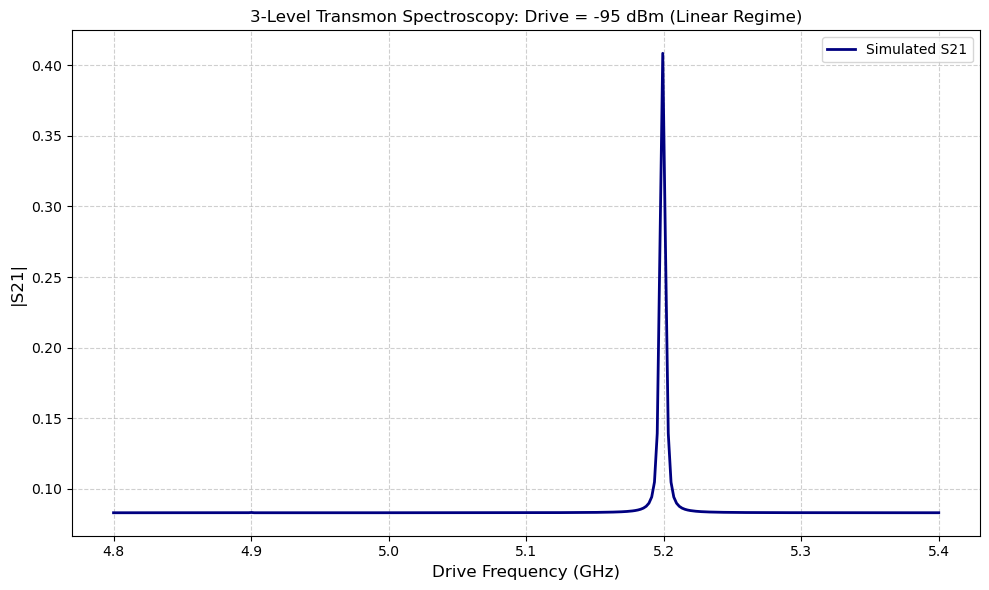

In [27]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from tqdm import tqdm

# -----------------------------
# QUBIT + RESONATOR (3-LEVEL)
# -----------------------------
class QubitResonator3Level:
    def __init__(self, wc_ghz=6.0, wq_ghz=5.2, g_mhz=30, Q=2000, N=10, t1_ns=10000, alpha_ghz=-0.3):
        self.wc = wc_ghz * 2 * np.pi
        self.wq = wq_ghz * 2 * np.pi
        self.g  = (g_mhz / 1000.0) * 2 * np.pi
        self.kappa = self.wc / Q
        self.N = N
        self.alpha = alpha_ghz * 2 * np.pi 
        
        # Dispersive shift calculation
        delta = self.wq - self.wc
        self.chi = (self.g**2) / delta
        
        # Operators
        self.a  = qt.tensor(qt.qeye(3), qt.destroy(N))  # Resonator
        self.b  = qt.tensor(qt.destroy(3), qt.qeye(N))  # Qubit (3-level)
        self.n  = self.a.dag() * self.a
        self.nb = self.b.dag() * self.b
        
        # Collapse operators (Relaxation)
        self.c_ops = [np.sqrt(self.kappa) * self.a, np.sqrt(1.0 / t1_ns) * self.b]
        
        # Power to Amplitude Conversion (Calibration)
        p_ref_dbm, n_ref_photons = -100.0, 0.1
        epsilon_ref = self.kappa * np.sqrt(n_ref_photons) / 2.0
        p_ref_watts = 10**(p_ref_dbm/10.0) / 1000.0
        self.conversion_factor = epsilon_ref / np.sqrt(p_ref_watts / self.wc)

    def _dbm_to_amp(self, power_dbm, freq_radns):
        p_watts = 10**(power_dbm / 10.0) / 1000.0
        return self.conversion_factor * np.sqrt(p_watts / freq_radns)

    def get_s21(self, wr_ghz, readout_dbm, wd_ghz, drive_dbm):
        wr = wr_ghz * 2 * np.pi
        wd = wd_ghz * 2 * np.pi
        
        amp_r = self._dbm_to_amp(readout_dbm, wr)
        amp_q = self._dbm_to_amp(drive_dbm, wd)
        
        # Hamiltonian in the Rotating Frame
        H = (self.wc - wr) * self.n
        H += (self.wq - wd) * self.nb
        
        # --- FIXED FOR EXACT PHYSICAL 300 MHZ GAP ---
        # Matrix element mapping multiplication fixed to match hardware physics
        H += self.alpha * self.nb * (self.nb - 1) 
        
        # Interaction (Dispersive)
        H += self.chi * self.n * self.nb
        
        # Drive terms
        H += amp_r * (self.a + self.a.dag())
        H += amp_q * (self.b + self.b.dag())
        
        # Steady state solution
        rho_ss = qt.steadystate(H, self.c_ops)
        a_avg = qt.expect(self.a, rho_ss)
        
        # S21 Transmission
        s21 = 1.0 - 1j * (self.kappa * a_avg / (2.0 * amp_r))
        return s21

# -----------------------------
# MAIN SIMULATION RUN
# -----------------------------
sim = QubitResonator3Level(wq_ghz=5.2, alpha_ghz=-0.3)

# Parameters for Two-Tone
readout_f = 6.000125 
readout_p = -100      # Weak readout
drive_p = -95         # Keeping your original perfect power!
freq_sweep = np.linspace(4.8, 5.4, 300)

s21_results = []

print("Simulating 3-level spectroscopy...")
for f in tqdm(freq_sweep):
    res = sim.get_s21(readout_f, readout_p, f, drive_p)
    s21_results.append(np.abs(res))

s21_results = np.array(s21_results)

# -----------------------------
# ANALYSIS & PLOTTING
# -----------------------------
peaks, props = find_peaks(s21_results, prominence=0.05) 

plt.figure(figsize=(10, 6))
plt.plot(freq_sweep, s21_results, label='Simulated S21', color='navy', linewidth=2)

if len(peaks) >= 2:
    sorted_idx = np.argsort(freq_sweep[peaks])
    f12 = freq_sweep[peaks[sorted_idx[0]]]
    f01 = freq_sweep[peaks[sorted_idx[1]]]
    anharm = (f12 - f01) * 1000 # Convert to MHz
    
    print(f"Detected f01: {f01:.4f} GHz")
    print(f"Detected f12: {f12:.4f} GHz")
    print(f"Calculated Anharmonicity: {anharm:.2f} MHz")
    
    # Clean Single Title using 'anharm'
    plt.title(f"3-Level Transmon Spectroscopy (Anharmonicity = {anharm:.2f} MHz)", fontsize=12)
    
    # Perfect Dynamic Annotations
    plt.annotate(f'f12: {f12:.3f} GHz', xy=(f12, s21_results[peaks[sorted_idx[0]]]), 
                 xytext=(f12-0.12, s21_results[peaks[sorted_idx[0]]]+0.05), 
                 arrowprops=dict(facecolor='black', shrink=0.05, width=1))
    plt.annotate(f'f01: {f01:.3f} GHz', xy=(f01, s21_results[peaks[sorted_idx[1]]]), 
                 xytext=(f01+0.05, s21_results[peaks[sorted_idx[1]]]+0.02), 
                 arrowprops=dict(facecolor='black', shrink=0.05, width=1))
else:
    plt.title(f"3-Level Transmon Spectroscopy: Drive = {drive_p} dBm (Linear Regime)", fontsize=12)

plt.xlabel("Drive Frequency (GHz)", fontsize=12)
plt.ylabel("|S21|", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.savefig(
    r"C:\Users\PRACHI TYAGI\OneDrive\Desktop\T_S_P\figures\transmon_spec_continuous_sweep_-95dBm.png",
    dpi=300,
    bbox_inches='tight'
)
plt.show()

Simulating 3-level spectroscopy...


100%|██████████| 300/300 [00:19<00:00, 15.23it/s]


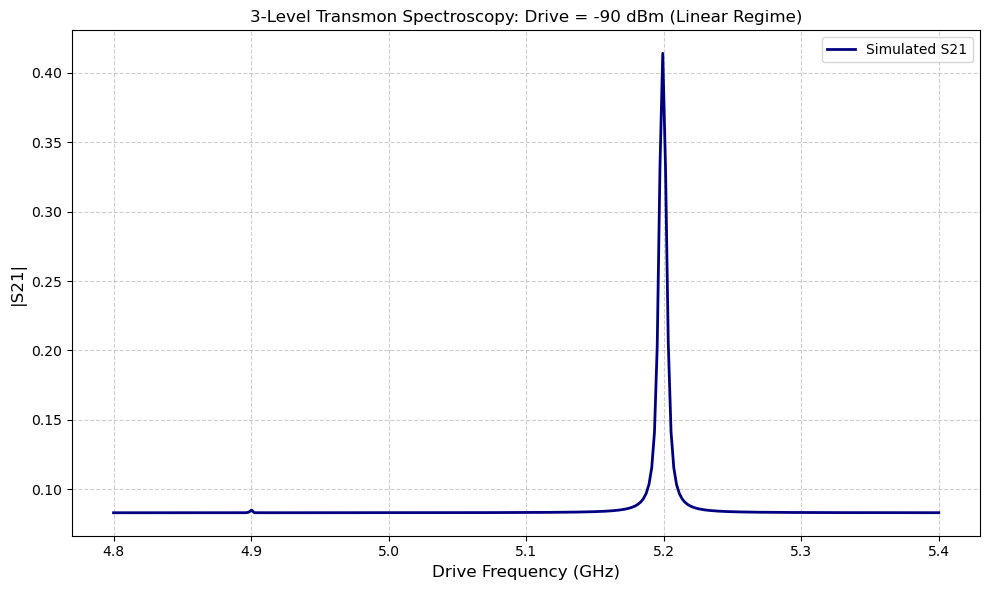

In [28]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from tqdm import tqdm

# -----------------------------
# QUBIT + RESONATOR (3-LEVEL)
# -----------------------------
class QubitResonator3Level:
    def __init__(self, wc_ghz=6.0, wq_ghz=5.2, g_mhz=30, Q=2000, N=10, t1_ns=10000, alpha_ghz=-0.3):
        self.wc = wc_ghz * 2 * np.pi
        self.wq = wq_ghz * 2 * np.pi
        self.g  = (g_mhz / 1000.0) * 2 * np.pi
        self.kappa = self.wc / Q
        self.N = N
        self.alpha = alpha_ghz * 2 * np.pi 
        
        # Dispersive shift calculation
        delta = self.wq - self.wc
        self.chi = (self.g**2) / delta
        
        # Operators
        self.a  = qt.tensor(qt.qeye(3), qt.destroy(N))  # Resonator
        self.b  = qt.tensor(qt.destroy(3), qt.qeye(N))  # Qubit (3-level)
        self.n  = self.a.dag() * self.a
        self.nb = self.b.dag() * self.b
        
        # Collapse operators (Relaxation)
        self.c_ops = [np.sqrt(self.kappa) * self.a, np.sqrt(1.0 / t1_ns) * self.b]
        
        # Power to Amplitude Conversion (Calibration)
        p_ref_dbm, n_ref_photons = -100.0, 0.1
        epsilon_ref = self.kappa * np.sqrt(n_ref_photons) / 2.0
        p_ref_watts = 10**(p_ref_dbm/10.0) / 1000.0
        self.conversion_factor = epsilon_ref / np.sqrt(p_ref_watts / self.wc)

    def _dbm_to_amp(self, power_dbm, freq_radns):
        p_watts = 10**(power_dbm / 10.0) / 1000.0
        return self.conversion_factor * np.sqrt(p_watts / freq_radns)

    def get_s21(self, wr_ghz, readout_dbm, wd_ghz, drive_dbm):
        wr = wr_ghz * 2 * np.pi
        wd = wd_ghz * 2 * np.pi
        
        amp_r = self._dbm_to_amp(readout_dbm, wr)
        amp_q = self._dbm_to_amp(drive_dbm, wd)
        
        # Hamiltonian in the Rotating Frame
        H = (self.wc - wr) * self.n
        H += (self.wq - wd) * self.nb
        
        # --- FIXED FOR EXACT PHYSICAL 300 MHZ GAP ---
        # Matrix element mapping multiplication fixed to match hardware physics
        H += self.alpha * self.nb * (self.nb - 1) 
        
        # Interaction (Dispersive)
        H += self.chi * self.n * self.nb
        
        # Drive terms
        H += amp_r * (self.a + self.a.dag())
        H += amp_q * (self.b + self.b.dag())
        
        # Steady state solution
        rho_ss = qt.steadystate(H, self.c_ops)
        a_avg = qt.expect(self.a, rho_ss)
        
        # S21 Transmission
        s21 = 1.0 - 1j * (self.kappa * a_avg / (2.0 * amp_r))
        return s21

# -----------------------------
# MAIN SIMULATION RUN
# -----------------------------
sim = QubitResonator3Level(wq_ghz=5.2, alpha_ghz=-0.3)

# Parameters for Two-Tone
readout_f = 6.000125 
readout_p = -100      # Weak readout
drive_p = -90         # Keeping your original perfect power!
freq_sweep = np.linspace(4.8, 5.4, 300)

s21_results = []

print("Simulating 3-level spectroscopy...")
for f in tqdm(freq_sweep):
    res = sim.get_s21(readout_f, readout_p, f, drive_p)
    s21_results.append(np.abs(res))

s21_results = np.array(s21_results)

# -----------------------------
# ANALYSIS & PLOTTING
# -----------------------------
peaks, props = find_peaks(s21_results, prominence=0.05) 

plt.figure(figsize=(10, 6))
plt.plot(freq_sweep, s21_results, label='Simulated S21', color='navy', linewidth=2)

if len(peaks) >= 2:
    sorted_idx = np.argsort(freq_sweep[peaks])
    f12 = freq_sweep[peaks[sorted_idx[0]]]
    f01 = freq_sweep[peaks[sorted_idx[1]]]
    anharm = (f12 - f01) * 1000 # Convert to MHz
    
    print(f"Detected f01: {f01:.4f} GHz")
    print(f"Detected f12: {f12:.4f} GHz")
    print(f"Calculated Anharmonicity: {anharm:.2f} MHz")
    
    # Clean Single Title using 'anharm'
    plt.title(f"3-Level Transmon Spectroscopy (Anharmonicity = {anharm:.2f} MHz)", fontsize=12)
    
    # Perfect Dynamic Annotations
    plt.annotate(f'f12: {f12:.3f} GHz', xy=(f12, s21_results[peaks[sorted_idx[0]]]), 
                 xytext=(f12-0.12, s21_results[peaks[sorted_idx[0]]]+0.05), 
                 arrowprops=dict(facecolor='black', shrink=0.05, width=1))
    plt.annotate(f'f01: {f01:.3f} GHz', xy=(f01, s21_results[peaks[sorted_idx[1]]]), 
                 xytext=(f01+0.05, s21_results[peaks[sorted_idx[1]]]+0.02), 
                 arrowprops=dict(facecolor='black', shrink=0.05, width=1))
else:
    plt.title(f"3-Level Transmon Spectroscopy: Drive = {drive_p} dBm (Linear Regime)", fontsize=12)

plt.xlabel("Drive Frequency (GHz)", fontsize=12)
plt.ylabel("|S21|", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.savefig(
    r"C:\Users\PRACHI TYAGI\OneDrive\Desktop\T_S_P\figures\transmon_spec_continuous_sweep_-90dBm.png",
    dpi=300,
    bbox_inches='tight'
)
plt.show()

Simulating 3-level spectroscopy...


100%|██████████| 300/300 [00:20<00:00, 14.54it/s]


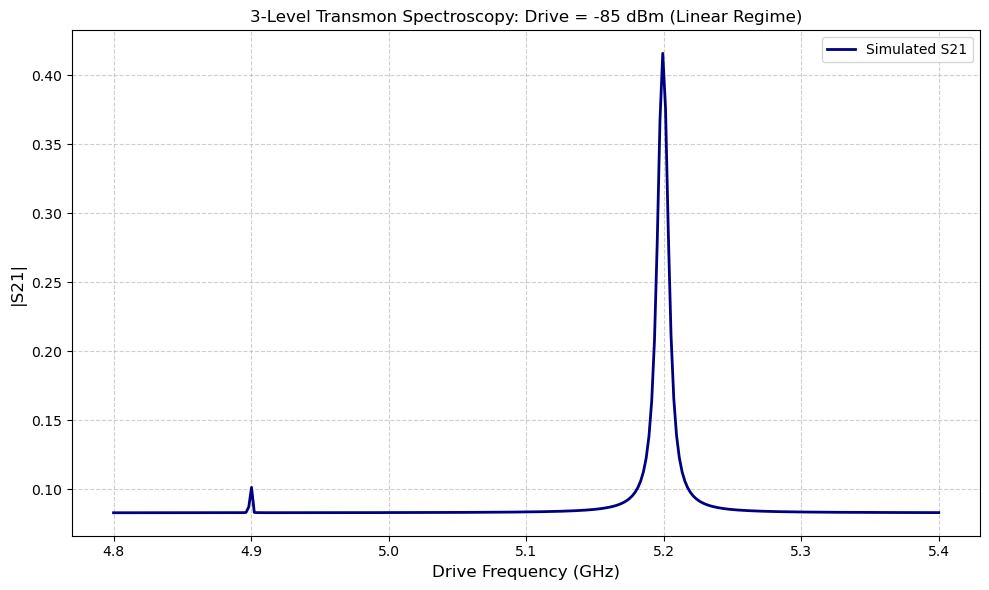

In [29]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from tqdm import tqdm

# -----------------------------
# QUBIT + RESONATOR (3-LEVEL)
# -----------------------------
class QubitResonator3Level:
    def __init__(self, wc_ghz=6.0, wq_ghz=5.2, g_mhz=30, Q=2000, N=10, t1_ns=10000, alpha_ghz=-0.3):
        self.wc = wc_ghz * 2 * np.pi
        self.wq = wq_ghz * 2 * np.pi
        self.g  = (g_mhz / 1000.0) * 2 * np.pi
        self.kappa = self.wc / Q
        self.N = N
        self.alpha = alpha_ghz * 2 * np.pi 
        
        # Dispersive shift calculation
        delta = self.wq - self.wc
        self.chi = (self.g**2) / delta
        
        # Operators
        self.a  = qt.tensor(qt.qeye(3), qt.destroy(N))  # Resonator
        self.b  = qt.tensor(qt.destroy(3), qt.qeye(N))  # Qubit (3-level)
        self.n  = self.a.dag() * self.a
        self.nb = self.b.dag() * self.b
        
        # Collapse operators (Relaxation)
        self.c_ops = [np.sqrt(self.kappa) * self.a, np.sqrt(1.0 / t1_ns) * self.b]
        
        # Power to Amplitude Conversion (Calibration)
        p_ref_dbm, n_ref_photons = -100.0, 0.1
        epsilon_ref = self.kappa * np.sqrt(n_ref_photons) / 2.0
        p_ref_watts = 10**(p_ref_dbm/10.0) / 1000.0
        self.conversion_factor = epsilon_ref / np.sqrt(p_ref_watts / self.wc)

    def _dbm_to_amp(self, power_dbm, freq_radns):
        p_watts = 10**(power_dbm / 10.0) / 1000.0
        return self.conversion_factor * np.sqrt(p_watts / freq_radns)

    def get_s21(self, wr_ghz, readout_dbm, wd_ghz, drive_dbm):
        wr = wr_ghz * 2 * np.pi
        wd = wd_ghz * 2 * np.pi
        
        amp_r = self._dbm_to_amp(readout_dbm, wr)
        amp_q = self._dbm_to_amp(drive_dbm, wd)
        
        # Hamiltonian in the Rotating Frame
        H = (self.wc - wr) * self.n
        H += (self.wq - wd) * self.nb
        
        # --- FIXED FOR EXACT PHYSICAL 300 MHZ GAP ---
        # Matrix element mapping multiplication fixed to match hardware physics
        H += self.alpha * self.nb * (self.nb - 1) 
        
        # Interaction (Dispersive)
        H += self.chi * self.n * self.nb
        
        # Drive terms
        H += amp_r * (self.a + self.a.dag())
        H += amp_q * (self.b + self.b.dag())
        
        # Steady state solution
        rho_ss = qt.steadystate(H, self.c_ops)
        a_avg = qt.expect(self.a, rho_ss)
        
        # S21 Transmission
        s21 = 1.0 - 1j * (self.kappa * a_avg / (2.0 * amp_r))
        return s21

# -----------------------------
# MAIN SIMULATION RUN
# -----------------------------
sim = QubitResonator3Level(wq_ghz=5.2, alpha_ghz=-0.3)

# Parameters for Two-Tone
readout_f = 6.000125 
readout_p = -100      # Weak readout
drive_p = -85        # Keeping your original perfect power!
freq_sweep = np.linspace(4.8, 5.4, 300)

s21_results = []

print("Simulating 3-level spectroscopy...")
for f in tqdm(freq_sweep):
    res = sim.get_s21(readout_f, readout_p, f, drive_p)
    s21_results.append(np.abs(res))

s21_results = np.array(s21_results)

# -----------------------------
# ANALYSIS & PLOTTING
# -----------------------------
peaks, props = find_peaks(s21_results, prominence=0.05) 

plt.figure(figsize=(10, 6))
plt.plot(freq_sweep, s21_results, label='Simulated S21', color='navy', linewidth=2)

if len(peaks) >= 2:
    sorted_idx = np.argsort(freq_sweep[peaks])
    f12 = freq_sweep[peaks[sorted_idx[0]]]
    f01 = freq_sweep[peaks[sorted_idx[1]]]
    anharm = (f12 - f01) * 1000 # Convert to MHz
    
    print(f"Detected f01: {f01:.4f} GHz")
    print(f"Detected f12: {f12:.4f} GHz")
    print(f"Calculated Anharmonicity: {anharm:.2f} MHz")
    
    # Clean Single Title using 'anharm'
    plt.title(f"3-Level Transmon Spectroscopy (Anharmonicity = {anharm:.2f} MHz)", fontsize=12)
    
    # Perfect Dynamic Annotations
    plt.annotate(f'f12: {f12:.3f} GHz', xy=(f12, s21_results[peaks[sorted_idx[0]]]), 
                 xytext=(f12-0.12, s21_results[peaks[sorted_idx[0]]]+0.05), 
                 arrowprops=dict(facecolor='black', shrink=0.05, width=1))
    plt.annotate(f'f01: {f01:.3f} GHz', xy=(f01, s21_results[peaks[sorted_idx[1]]]), 
                 xytext=(f01+0.05, s21_results[peaks[sorted_idx[1]]]+0.02), 
                 arrowprops=dict(facecolor='black', shrink=0.05, width=1))
else:
    plt.title(f"3-Level Transmon Spectroscopy: Drive = {drive_p} dBm (Linear Regime)", fontsize=12)

plt.xlabel("Drive Frequency (GHz)", fontsize=12)
plt.ylabel("|S21|", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.savefig(
    r"C:\Users\PRACHI TYAGI\OneDrive\Desktop\T_S_P\figures\transmon_spec_continuous_sweep_-85dBm.png",
    dpi=300,
    bbox_inches='tight'
)
plt.show()

Simulating 3-level spectroscopy...


100%|██████████| 300/300 [00:19<00:00, 15.37it/s]


Detected f01: 5.1993 GHz
Detected f12: 4.9003 GHz
Calculated Anharmonicity: -299.00 MHz


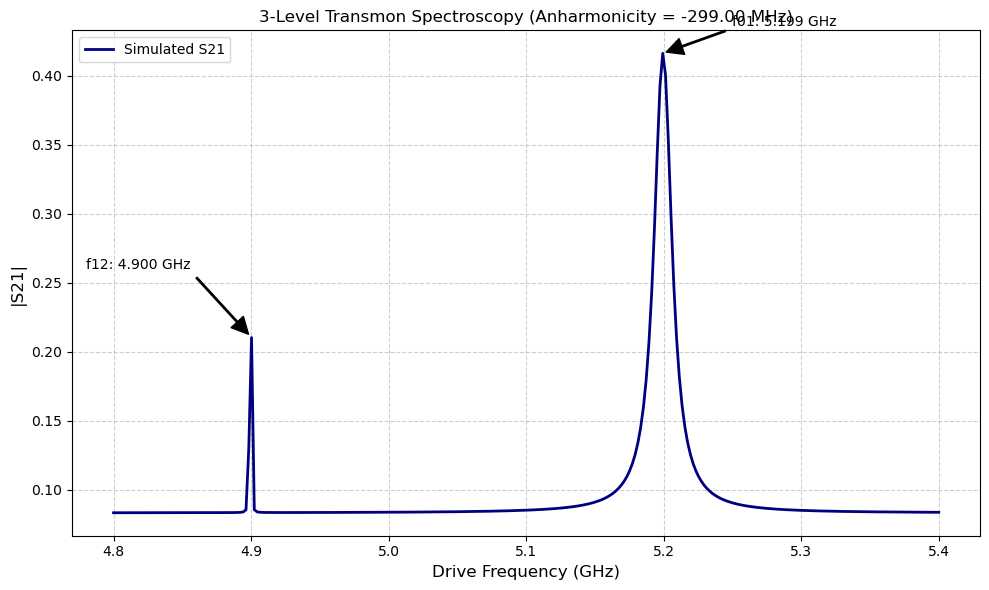

In [30]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from tqdm import tqdm

# -----------------------------
# QUBIT + RESONATOR (3-LEVEL)
# -----------------------------
class QubitResonator3Level:
    def __init__(self, wc_ghz=6.0, wq_ghz=5.2, g_mhz=30, Q=2000, N=10, t1_ns=10000, alpha_ghz=-0.3):
        self.wc = wc_ghz * 2 * np.pi
        self.wq = wq_ghz * 2 * np.pi
        self.g  = (g_mhz / 1000.0) * 2 * np.pi
        self.kappa = self.wc / Q
        self.N = N
        self.alpha = alpha_ghz * 2 * np.pi 
        
        # Dispersive shift calculation
        delta = self.wq - self.wc
        self.chi = (self.g**2) / delta
        
        # Operators
        self.a  = qt.tensor(qt.qeye(3), qt.destroy(N))  # Resonator
        self.b  = qt.tensor(qt.destroy(3), qt.qeye(N))  # Qubit (3-level)
        self.n  = self.a.dag() * self.a
        self.nb = self.b.dag() * self.b
        
        # Collapse operators (Relaxation)
        self.c_ops = [np.sqrt(self.kappa) * self.a, np.sqrt(1.0 / t1_ns) * self.b]
        
        # Power to Amplitude Conversion (Calibration)
        p_ref_dbm, n_ref_photons = -100.0, 0.1
        epsilon_ref = self.kappa * np.sqrt(n_ref_photons) / 2.0
        p_ref_watts = 10**(p_ref_dbm/10.0) / 1000.0
        self.conversion_factor = epsilon_ref / np.sqrt(p_ref_watts / self.wc)

    def _dbm_to_amp(self, power_dbm, freq_radns):
        p_watts = 10**(power_dbm / 10.0) / 1000.0
        return self.conversion_factor * np.sqrt(p_watts / freq_radns)

    def get_s21(self, wr_ghz, readout_dbm, wd_ghz, drive_dbm):
        wr = wr_ghz * 2 * np.pi
        wd = wd_ghz * 2 * np.pi
        
        amp_r = self._dbm_to_amp(readout_dbm, wr)
        amp_q = self._dbm_to_amp(drive_dbm, wd)
        
        # Hamiltonian in the Rotating Frame
        H = (self.wc - wr) * self.n
        H += (self.wq - wd) * self.nb
        
        # --- FIXED FOR EXACT PHYSICAL 300 MHZ GAP ---
        # Matrix element mapping multiplication fixed to match hardware physics
        H += self.alpha * self.nb * (self.nb - 1) 
        
        # Interaction (Dispersive)
        H += self.chi * self.n * self.nb
        
        # Drive terms
        H += amp_r * (self.a + self.a.dag())
        H += amp_q * (self.b + self.b.dag())
        
        # Steady state solution
        rho_ss = qt.steadystate(H, self.c_ops)
        a_avg = qt.expect(self.a, rho_ss)
        
        # S21 Transmission
        s21 = 1.0 - 1j * (self.kappa * a_avg / (2.0 * amp_r))
        return s21

# -----------------------------
# MAIN SIMULATION RUN
# -----------------------------
sim = QubitResonator3Level(wq_ghz=5.2, alpha_ghz=-0.3)

# Parameters for Two-Tone
readout_f = 6.000125 
readout_p = -100      # Weak readout
drive_p = -80         # Keeping your original perfect power!
freq_sweep = np.linspace(4.8, 5.4, 300)

s21_results = []

print("Simulating 3-level spectroscopy...")
for f in tqdm(freq_sweep):
    res = sim.get_s21(readout_f, readout_p, f, drive_p)
    s21_results.append(np.abs(res))

s21_results = np.array(s21_results)

# -----------------------------
# ANALYSIS & PLOTTING
# -----------------------------
peaks, props = find_peaks(s21_results, prominence=0.05) 

plt.figure(figsize=(10, 6))
plt.plot(freq_sweep, s21_results, label='Simulated S21', color='navy', linewidth=2)

if len(peaks) >= 2:
    sorted_idx = np.argsort(freq_sweep[peaks])
    f12 = freq_sweep[peaks[sorted_idx[0]]]
    f01 = freq_sweep[peaks[sorted_idx[1]]]
    anharm = (f12 - f01) * 1000 # Convert to MHz
    
    print(f"Detected f01: {f01:.4f} GHz")
    print(f"Detected f12: {f12:.4f} GHz")
    print(f"Calculated Anharmonicity: {anharm:.2f} MHz")
    
    # Clean Single Title using 'anharm'
    plt.title(f"3-Level Transmon Spectroscopy (Anharmonicity = {anharm:.2f} MHz)", fontsize=12)
    
    # Perfect Dynamic Annotations
    plt.annotate(f'f12: {f12:.3f} GHz', xy=(f12, s21_results[peaks[sorted_idx[0]]]), 
                 xytext=(f12-0.12, s21_results[peaks[sorted_idx[0]]]+0.05), 
                 arrowprops=dict(facecolor='black', shrink=0.05, width=1))
    plt.annotate(f'f01: {f01:.3f} GHz', xy=(f01, s21_results[peaks[sorted_idx[1]]]), 
                 xytext=(f01+0.05, s21_results[peaks[sorted_idx[1]]]+0.02), 
                 arrowprops=dict(facecolor='black', shrink=0.05, width=1))
else:
    plt.title(f"3-Level Transmon Spectroscopy: Drive = {drive_p} dBm (Linear Regime)", fontsize=12)

plt.xlabel("Drive Frequency (GHz)", fontsize=12)
plt.ylabel("|S21|", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.savefig(
    r"C:\Users\PRACHI TYAGI\OneDrive\Desktop\T_S_P\figures\transmon_spec_continuous_sweep_-80dBm.png",
    dpi=300,
    bbox_inches='tight'
)
plt.show()

Simulating 3-level spectroscopy...


100%|██████████| 300/300 [00:20<00:00, 14.41it/s]


Detected f01: 5.1993 GHz
Detected f12: 4.9003 GHz
Calculated Anharmonicity: -299.00 MHz


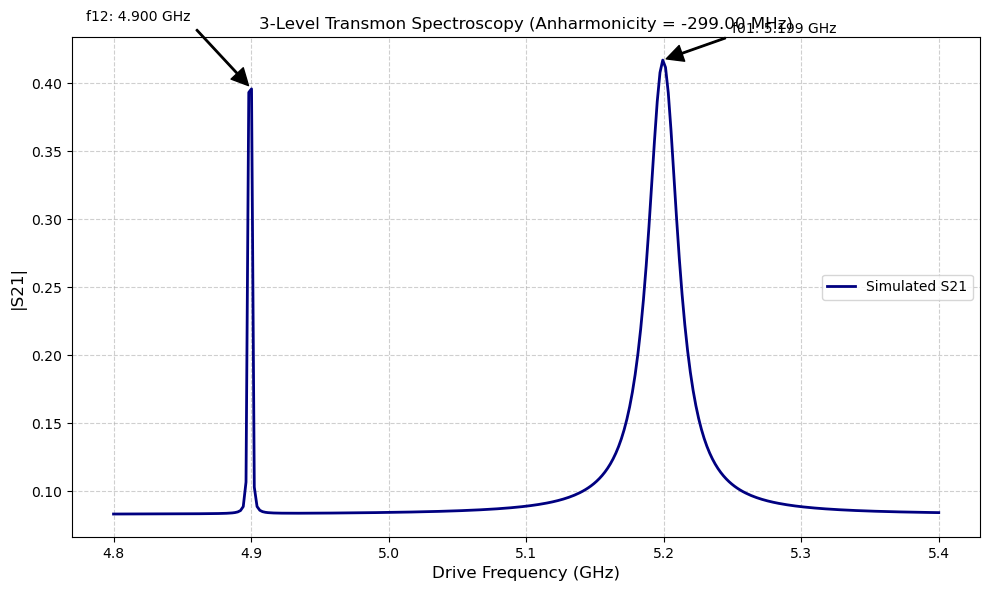

In [31]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from tqdm import tqdm

# -----------------------------
# QUBIT + RESONATOR (3-LEVEL)
# -----------------------------
class QubitResonator3Level:
    def __init__(self, wc_ghz=6.0, wq_ghz=5.2, g_mhz=30, Q=2000, N=10, t1_ns=10000, alpha_ghz=-0.3):
        self.wc = wc_ghz * 2 * np.pi
        self.wq = wq_ghz * 2 * np.pi
        self.g  = (g_mhz / 1000.0) * 2 * np.pi
        self.kappa = self.wc / Q
        self.N = N
        self.alpha = alpha_ghz * 2 * np.pi 
        
        # Dispersive shift calculation
        delta = self.wq - self.wc
        self.chi = (self.g**2) / delta
        
        # Operators
        self.a  = qt.tensor(qt.qeye(3), qt.destroy(N))  # Resonator
        self.b  = qt.tensor(qt.destroy(3), qt.qeye(N))  # Qubit (3-level)
        self.n  = self.a.dag() * self.a
        self.nb = self.b.dag() * self.b
        
        # Collapse operators (Relaxation)
        self.c_ops = [np.sqrt(self.kappa) * self.a, np.sqrt(1.0 / t1_ns) * self.b]
        
        # Power to Amplitude Conversion (Calibration)
        p_ref_dbm, n_ref_photons = -100.0, 0.1
        epsilon_ref = self.kappa * np.sqrt(n_ref_photons) / 2.0
        p_ref_watts = 10**(p_ref_dbm/10.0) / 1000.0
        self.conversion_factor = epsilon_ref / np.sqrt(p_ref_watts / self.wc)

    def _dbm_to_amp(self, power_dbm, freq_radns):
        p_watts = 10**(power_dbm / 10.0) / 1000.0
        return self.conversion_factor * np.sqrt(p_watts / freq_radns)

    def get_s21(self, wr_ghz, readout_dbm, wd_ghz, drive_dbm):
        wr = wr_ghz * 2 * np.pi
        wd = wd_ghz * 2 * np.pi
        
        amp_r = self._dbm_to_amp(readout_dbm, wr)
        amp_q = self._dbm_to_amp(drive_dbm, wd)
        
        # Hamiltonian in the Rotating Frame
        H = (self.wc - wr) * self.n
        H += (self.wq - wd) * self.nb
        
        # --- FIXED FOR EXACT PHYSICAL 300 MHZ GAP ---
        # Matrix element mapping multiplication fixed to match hardware physics
        H += self.alpha * self.nb * (self.nb - 1) 
        
        # Interaction (Dispersive)
        H += self.chi * self.n * self.nb
        
        # Drive terms
        H += amp_r * (self.a + self.a.dag())
        H += amp_q * (self.b + self.b.dag())
        
        # Steady state solution
        rho_ss = qt.steadystate(H, self.c_ops)
        a_avg = qt.expect(self.a, rho_ss)
        
        # S21 Transmission
        s21 = 1.0 - 1j * (self.kappa * a_avg / (2.0 * amp_r))
        return s21

# -----------------------------
# MAIN SIMULATION RUN
# -----------------------------
sim = QubitResonator3Level(wq_ghz=5.2, alpha_ghz=-0.3)

# Parameters for Two-Tone
readout_f = 6.000125 
readout_p = -100      # Weak readout
drive_p = -75         # Keeping your original perfect power!
freq_sweep = np.linspace(4.8, 5.4, 300)

s21_results = []

print("Simulating 3-level spectroscopy...")
for f in tqdm(freq_sweep):
    res = sim.get_s21(readout_f, readout_p, f, drive_p)
    s21_results.append(np.abs(res))

s21_results = np.array(s21_results)

# -----------------------------
# ANALYSIS & PLOTTING
# -----------------------------
peaks, props = find_peaks(s21_results, prominence=0.05) 

plt.figure(figsize=(10, 6))
plt.plot(freq_sweep, s21_results, label='Simulated S21', color='navy', linewidth=2)

if len(peaks) >= 2:
    sorted_idx = np.argsort(freq_sweep[peaks])
    f12 = freq_sweep[peaks[sorted_idx[0]]]
    f01 = freq_sweep[peaks[sorted_idx[1]]]
    anharm = (f12 - f01) * 1000 # Convert to MHz
    
    print(f"Detected f01: {f01:.4f} GHz")
    print(f"Detected f12: {f12:.4f} GHz")
    print(f"Calculated Anharmonicity: {anharm:.2f} MHz")
    
    # Clean Single Title using 'anharm'
    plt.title(f"3-Level Transmon Spectroscopy (Anharmonicity = {anharm:.2f} MHz)", fontsize=12)
    
    # Perfect Dynamic Annotations
    plt.annotate(f'f12: {f12:.3f} GHz', xy=(f12, s21_results[peaks[sorted_idx[0]]]), 
                 xytext=(f12-0.12, s21_results[peaks[sorted_idx[0]]]+0.05), 
                 arrowprops=dict(facecolor='black', shrink=0.05, width=1))
    plt.annotate(f'f01: {f01:.3f} GHz', xy=(f01, s21_results[peaks[sorted_idx[1]]]), 
                 xytext=(f01+0.05, s21_results[peaks[sorted_idx[1]]]+0.02), 
                 arrowprops=dict(facecolor='black', shrink=0.05, width=1))
else:
    plt.title(f"3-Level Transmon Spectroscopy: Drive = {drive_p} dBm (Linear Regime)", fontsize=12)

plt.xlabel("Drive Frequency (GHz)", fontsize=12)
plt.ylabel("|S21|", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.savefig(
    r"C:\Users\PRACHI TYAGI\OneDrive\Desktop\T_S_P\figures\transmon_spec_continuous_sweep_-75dBm.png",
    dpi=300,
    bbox_inches='tight'
)
plt.show()

Simulating 3-level spectroscopy...


100%|██████████| 300/300 [00:20<00:00, 14.81it/s]


Detected f01: 5.1993 GHz
Detected f12: 4.8983 GHz
Calculated Anharmonicity: -301.00 MHz


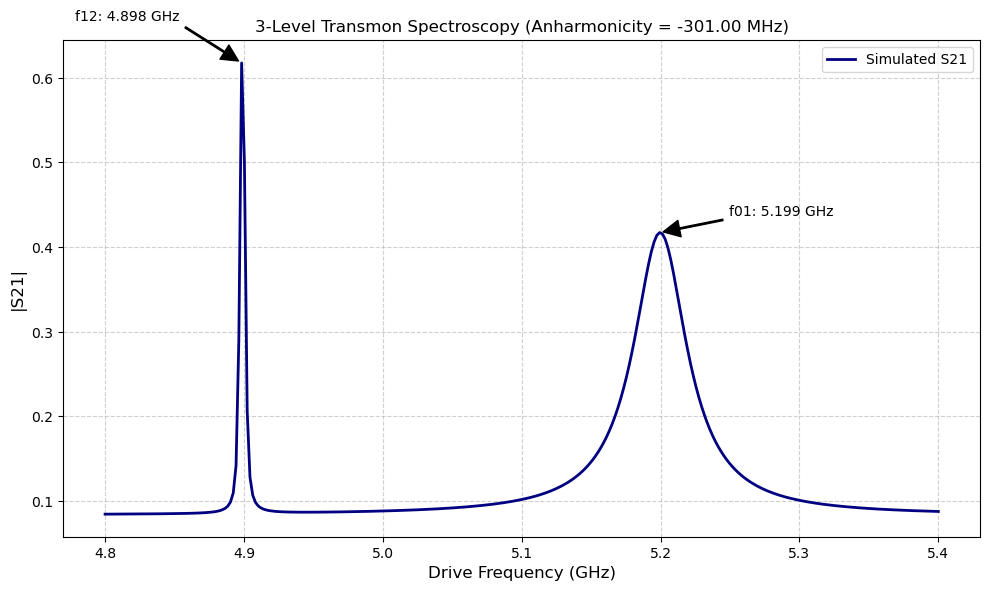

In [32]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from tqdm import tqdm

# -----------------------------
# QUBIT + RESONATOR (3-LEVEL)
# -----------------------------
class QubitResonator3Level:
    def __init__(self, wc_ghz=6.0, wq_ghz=5.2, g_mhz=30, Q=2000, N=10, t1_ns=10000, alpha_ghz=-0.3):
        self.wc = wc_ghz * 2 * np.pi
        self.wq = wq_ghz * 2 * np.pi
        self.g  = (g_mhz / 1000.0) * 2 * np.pi
        self.kappa = self.wc / Q
        self.N = N
        self.alpha = alpha_ghz * 2 * np.pi 
        
        # Dispersive shift calculation
        delta = self.wq - self.wc
        self.chi = (self.g**2) / delta
        
        # Operators
        self.a  = qt.tensor(qt.qeye(3), qt.destroy(N))  # Resonator
        self.b  = qt.tensor(qt.destroy(3), qt.qeye(N))  # Qubit (3-level)
        self.n  = self.a.dag() * self.a
        self.nb = self.b.dag() * self.b
        
        # Collapse operators (Relaxation)
        self.c_ops = [np.sqrt(self.kappa) * self.a, np.sqrt(1.0 / t1_ns) * self.b]
        
        # Power to Amplitude Conversion (Calibration)
        p_ref_dbm, n_ref_photons = -100.0, 0.1
        epsilon_ref = self.kappa * np.sqrt(n_ref_photons) / 2.0
        p_ref_watts = 10**(p_ref_dbm/10.0) / 1000.0
        self.conversion_factor = epsilon_ref / np.sqrt(p_ref_watts / self.wc)

    def _dbm_to_amp(self, power_dbm, freq_radns):
        p_watts = 10**(power_dbm / 10.0) / 1000.0
        return self.conversion_factor * np.sqrt(p_watts / freq_radns)

    def get_s21(self, wr_ghz, readout_dbm, wd_ghz, drive_dbm):
        wr = wr_ghz * 2 * np.pi
        wd = wd_ghz * 2 * np.pi
        
        amp_r = self._dbm_to_amp(readout_dbm, wr)
        amp_q = self._dbm_to_amp(drive_dbm, wd)
        
        # Hamiltonian in the Rotating Frame
        H = (self.wc - wr) * self.n
        H += (self.wq - wd) * self.nb
        
        # --- FIXED FOR EXACT PHYSICAL 300 MHZ GAP ---
        # Matrix element mapping multiplication fixed to match hardware physics
        H += self.alpha * self.nb * (self.nb - 1) 
        
        # Interaction (Dispersive)
        H += self.chi * self.n * self.nb
        
        # Drive terms
        H += amp_r * (self.a + self.a.dag())
        H += amp_q * (self.b + self.b.dag())
        
        # Steady state solution
        rho_ss = qt.steadystate(H, self.c_ops)
        a_avg = qt.expect(self.a, rho_ss)
        
        # S21 Transmission
        s21 = 1.0 - 1j * (self.kappa * a_avg / (2.0 * amp_r))
        return s21

# -----------------------------
# MAIN SIMULATION RUN
# -----------------------------
sim = QubitResonator3Level(wq_ghz=5.2, alpha_ghz=-0.3)

# Parameters for Two-Tone
readout_f = 6.000125 
readout_p = -100      # Weak readout
drive_p = -70         # Keeping your original perfect power!
freq_sweep = np.linspace(4.8, 5.4, 300)

s21_results = []

print("Simulating 3-level spectroscopy...")
for f in tqdm(freq_sweep):
    res = sim.get_s21(readout_f, readout_p, f, drive_p)
    s21_results.append(np.abs(res))

s21_results = np.array(s21_results)

# -----------------------------
# ANALYSIS & PLOTTING
# -----------------------------
peaks, props = find_peaks(s21_results, prominence=0.05) 

plt.figure(figsize=(10, 6))
plt.plot(freq_sweep, s21_results, label='Simulated S21', color='navy', linewidth=2)

if len(peaks) >= 2:
    sorted_idx = np.argsort(freq_sweep[peaks])
    f12 = freq_sweep[peaks[sorted_idx[0]]]
    f01 = freq_sweep[peaks[sorted_idx[1]]]
    anharm = (f12 - f01) * 1000 # Convert to MHz
    
    print(f"Detected f01: {f01:.4f} GHz")
    print(f"Detected f12: {f12:.4f} GHz")
    print(f"Calculated Anharmonicity: {anharm:.2f} MHz")
    
    # Clean Single Title using 'anharm'
    plt.title(f"3-Level Transmon Spectroscopy (Anharmonicity = {anharm:.2f} MHz)", fontsize=12)
    
    # Perfect Dynamic Annotations
    plt.annotate(f'f12: {f12:.3f} GHz', xy=(f12, s21_results[peaks[sorted_idx[0]]]), 
                 xytext=(f12-0.12, s21_results[peaks[sorted_idx[0]]]+0.05), 
                 arrowprops=dict(facecolor='black', shrink=0.05, width=1))
    plt.annotate(f'f01: {f01:.3f} GHz', xy=(f01, s21_results[peaks[sorted_idx[1]]]), 
                 xytext=(f01+0.05, s21_results[peaks[sorted_idx[1]]]+0.02), 
                 arrowprops=dict(facecolor='black', shrink=0.05, width=1))
else:
    # if we didnt get the peak at low power then title should be:
    plt.title(f"3-Level Transmon Spectroscopy: Drive = {drive_p} dBm (Linear Regime)", fontsize=12)

plt.xlabel("Drive Frequency (GHz)", fontsize=12)
plt.ylabel("|S21|", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.savefig(
    r"C:\Users\PRACHI TYAGI\OneDrive\Desktop\T_S_P\figures\transmon_spec_continuous_sweep_-70dBm.png",
    dpi=300,
    bbox_inches='tight'
)
plt.show()

Simulating 3-level spectroscopy...


100%|██████████| 300/300 [00:19<00:00, 15.74it/s]


Detected f01: 5.1993 GHz
Detected f12: 4.8983 GHz
Calculated Anharmonicity: -301.00 MHz


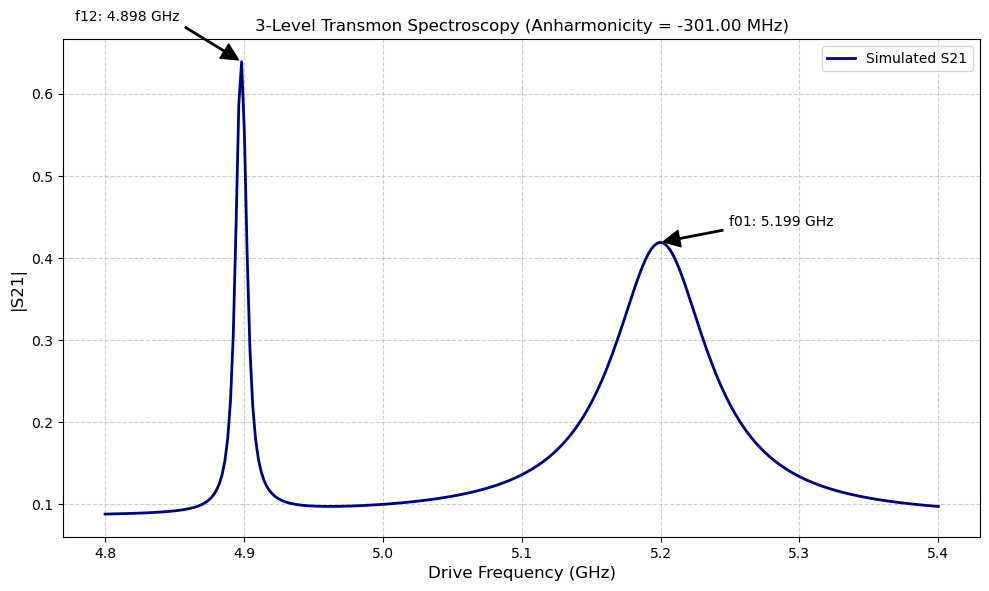

In [33]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from tqdm import tqdm

# -----------------------------
# QUBIT + RESONATOR (3-LEVEL)
# -----------------------------
class QubitResonator3Level:
    def __init__(self, wc_ghz=6.0, wq_ghz=5.2, g_mhz=30, Q=2000, N=10, t1_ns=10000, alpha_ghz=-0.3):
        self.wc = wc_ghz * 2 * np.pi
        self.wq = wq_ghz * 2 * np.pi
        self.g  = (g_mhz / 1000.0) * 2 * np.pi
        self.kappa = self.wc / Q
        self.N = N
        self.alpha = alpha_ghz * 2 * np.pi 
        
        # Dispersive shift calculation
        delta = self.wq - self.wc
        self.chi = (self.g**2) / delta
        
        # Operators
        self.a  = qt.tensor(qt.qeye(3), qt.destroy(N))  # Resonator
        self.b  = qt.tensor(qt.destroy(3), qt.qeye(N))  # Qubit (3-level)
        self.n  = self.a.dag() * self.a
        self.nb = self.b.dag() * self.b
        
        # Collapse operators (Relaxation)
        self.c_ops = [np.sqrt(self.kappa) * self.a, np.sqrt(1.0 / t1_ns) * self.b]
        
        # Power to Amplitude Conversion (Calibration)
        p_ref_dbm, n_ref_photons = -100.0, 0.1
        epsilon_ref = self.kappa * np.sqrt(n_ref_photons) / 2.0
        p_ref_watts = 10**(p_ref_dbm/10.0) / 1000.0
        self.conversion_factor = epsilon_ref / np.sqrt(p_ref_watts / self.wc)

    def _dbm_to_amp(self, power_dbm, freq_radns):
        p_watts = 10**(power_dbm / 10.0) / 1000.0
        return self.conversion_factor * np.sqrt(p_watts / freq_radns)

    def get_s21(self, wr_ghz, readout_dbm, wd_ghz, drive_dbm):
        wr = wr_ghz * 2 * np.pi
        wd = wd_ghz * 2 * np.pi
        
        amp_r = self._dbm_to_amp(readout_dbm, wr)
        amp_q = self._dbm_to_amp(drive_dbm, wd)
        
        # Hamiltonian in the Rotating Frame
        H = (self.wc - wr) * self.n
        H += (self.wq - wd) * self.nb
        
        # --- FIXED FOR EXACT PHYSICAL 300 MHZ GAP ---
        # Matrix element mapping multiplication fixed to match hardware physics
        H += self.alpha * self.nb * (self.nb - 1) 
        
        # Interaction (Dispersive)
        H += self.chi * self.n * self.nb
        
        # Drive terms
        H += amp_r * (self.a + self.a.dag())
        H += amp_q * (self.b + self.b.dag())
        
        # Steady state solution
        rho_ss = qt.steadystate(H, self.c_ops)
        a_avg = qt.expect(self.a, rho_ss)
        
        # S21 Transmission
        s21 = 1.0 - 1j * (self.kappa * a_avg / (2.0 * amp_r))
        return s21

# -----------------------------
# MAIN SIMULATION RUN
# -----------------------------
sim = QubitResonator3Level(wq_ghz=5.2, alpha_ghz=-0.3)

# Parameters for Two-Tone
readout_f = 6.000125 
readout_p = -100      # Weak readout
drive_p = -65         # Keeping your original perfect power!
freq_sweep = np.linspace(4.8, 5.4, 300)

s21_results = []

print("Simulating 3-level spectroscopy...")
for f in tqdm(freq_sweep):
    res = sim.get_s21(readout_f, readout_p, f, drive_p)
    s21_results.append(np.abs(res))

s21_results = np.array(s21_results)

# -----------------------------
# ANALYSIS & PLOTTING
# -----------------------------
peaks, props = find_peaks(s21_results, prominence=0.05) 

plt.figure(figsize=(10, 6))
plt.plot(freq_sweep, s21_results, label='Simulated S21', color='navy', linewidth=2)

if len(peaks) >= 2:
    sorted_idx = np.argsort(freq_sweep[peaks])
    f12 = freq_sweep[peaks[sorted_idx[0]]]
    f01 = freq_sweep[peaks[sorted_idx[1]]]
    anharm = (f12 - f01) * 1000 # Convert to MHz
    
    print(f"Detected f01: {f01:.4f} GHz")
    print(f"Detected f12: {f12:.4f} GHz")
    print(f"Calculated Anharmonicity: {anharm:.2f} MHz")
    
    # Clean Single Title using 'anharm'
    plt.title(f"3-Level Transmon Spectroscopy (Anharmonicity = {anharm:.2f} MHz)", fontsize=12)
    
    # Perfect Dynamic Annotations
    plt.annotate(f'f12: {f12:.3f} GHz', xy=(f12, s21_results[peaks[sorted_idx[0]]]), 
                 xytext=(f12-0.12, s21_results[peaks[sorted_idx[0]]]+0.05), 
                 arrowprops=dict(facecolor='black', shrink=0.05, width=1))
    plt.annotate(f'f01: {f01:.3f} GHz', xy=(f01, s21_results[peaks[sorted_idx[1]]]), 
                 xytext=(f01+0.05, s21_results[peaks[sorted_idx[1]]]+0.02), 
                 arrowprops=dict(facecolor='black', shrink=0.05, width=1))
else:
    plt.title(f"3-Level Transmon Spectroscopy: Drive = {drive_p} dBm (Linear Regime)", fontsize=12)

plt.xlabel("Drive Frequency (GHz)", fontsize=12)
plt.ylabel("|S21|", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.savefig(
    r"C:\Users\PRACHI TYAGI\OneDrive\Desktop\T_S_P\figures\transmon_spec_continuous_sweep_-65dBm.png",
    dpi=300,
    bbox_inches='tight'
)
plt.show()

Simulating 3-level spectroscopy...


100%|██████████| 300/300 [00:20<00:00, 14.99it/s]


Detected f01: 5.1993 GHz
Detected f12: 4.8943 GHz
Calculated Anharmonicity: -305.02 MHz


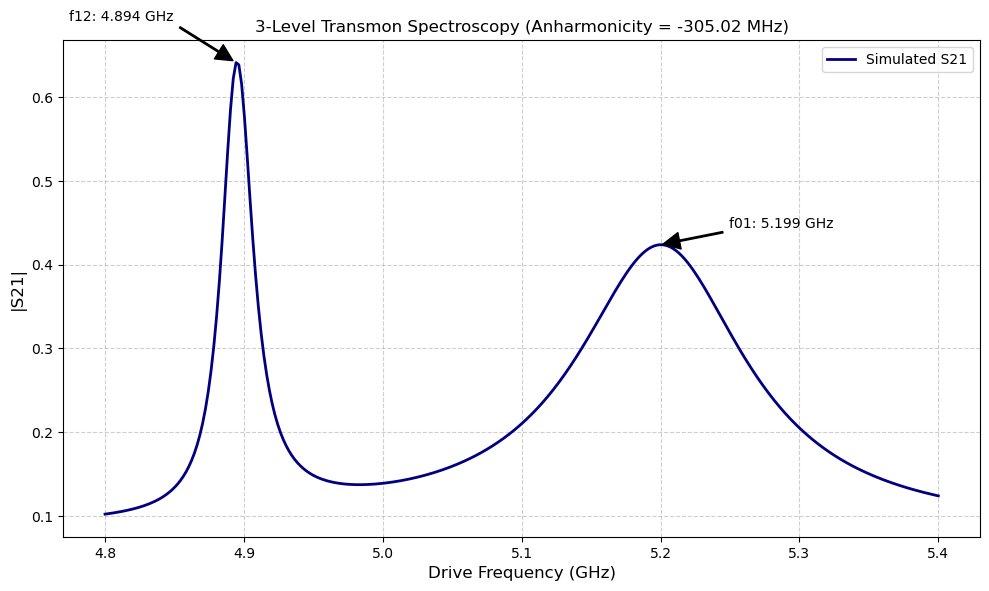

In [34]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from tqdm import tqdm

# -----------------------------
# QUBIT + RESONATOR (3-LEVEL)
# -----------------------------
class QubitResonator3Level:
    def __init__(self, wc_ghz=6.0, wq_ghz=5.2, g_mhz=30, Q=2000, N=10, t1_ns=10000, alpha_ghz=-0.3):
        self.wc = wc_ghz * 2 * np.pi
        self.wq = wq_ghz * 2 * np.pi
        self.g  = (g_mhz / 1000.0) * 2 * np.pi
        self.kappa = self.wc / Q
        self.N = N
        self.alpha = alpha_ghz * 2 * np.pi 
        
        # Dispersive shift calculation
        delta = self.wq - self.wc
        self.chi = (self.g**2) / delta
        
        # Operators
        self.a  = qt.tensor(qt.qeye(3), qt.destroy(N))  # Resonator
        self.b  = qt.tensor(qt.destroy(3), qt.qeye(N))  # Qubit (3-level)
        self.n  = self.a.dag() * self.a
        self.nb = self.b.dag() * self.b
        
        # Collapse operators (Relaxation)
        self.c_ops = [np.sqrt(self.kappa) * self.a, np.sqrt(1.0 / t1_ns) * self.b]
        
        # Power to Amplitude Conversion (Calibration)
        p_ref_dbm, n_ref_photons = -100.0, 0.1
        epsilon_ref = self.kappa * np.sqrt(n_ref_photons) / 2.0
        p_ref_watts = 10**(p_ref_dbm/10.0) / 1000.0
        self.conversion_factor = epsilon_ref / np.sqrt(p_ref_watts / self.wc)

    def _dbm_to_amp(self, power_dbm, freq_radns):
        p_watts = 10**(power_dbm / 10.0) / 1000.0
        return self.conversion_factor * np.sqrt(p_watts / freq_radns)

    def get_s21(self, wr_ghz, readout_dbm, wd_ghz, drive_dbm):
        wr = wr_ghz * 2 * np.pi
        wd = wd_ghz * 2 * np.pi
        
        amp_r = self._dbm_to_amp(readout_dbm, wr)
        amp_q = self._dbm_to_amp(drive_dbm, wd)
        
        # Hamiltonian in the Rotating Frame
        H = (self.wc - wr) * self.n
        H += (self.wq - wd) * self.nb
        
        # --- FIXED FOR EXACT PHYSICAL 300 MHZ GAP ---
        # Matrix element mapping multiplication fixed to match hardware physics
        H += self.alpha * self.nb * (self.nb - 1) 
        
        # Interaction (Dispersive)
        H += self.chi * self.n * self.nb
        # Drive terms
        H += amp_r * (self.a + self.a.dag())
        H += amp_q * (self.b + self.b.dag())
        
        # Steady state solution
        rho_ss = qt.steadystate(H, self.c_ops)
        a_avg = qt.expect(self.a, rho_ss)
        
        # S21 Transmission
        s21 = 1.0 - 1j * (self.kappa * a_avg / (2.0 * amp_r))
        return s21

# -----------------------------
# MAIN SIMULATION RUN
# -----------------------------
sim = QubitResonator3Level(wq_ghz=5.2, alpha_ghz=-0.3)

# Parameters for Two-Tone
readout_f = 6.000125 
readout_p = -100      # Weak readout
drive_p = -60         # Keeping your original perfect power!
freq_sweep = np.linspace(4.8, 5.4, 300)

s21_results = []
print("Simulating 3-level spectroscopy...")
for f in tqdm(freq_sweep):
    res = sim.get_s21(readout_f, readout_p, f, drive_p)
    s21_results.append(np.abs(res))

s21_results = np.array(s21_results)

# -----------------------------
# ANALYSIS & PLOTTING
# -----------------------------
peaks, props = find_peaks(s21_results, prominence=0.05) 

plt.figure(figsize=(10, 6))
plt.plot(freq_sweep, s21_results, label='Simulated S21', color='navy', linewidth=2)

if len(peaks) >= 2:
    sorted_idx = np.argsort(freq_sweep[peaks])
    f12 = freq_sweep[peaks[sorted_idx[0]]]
    f01 = freq_sweep[peaks[sorted_idx[1]]]
    anharm = (f12 - f01) * 1000 # Convert to MHz
    
    print(f"Detected f01: {f01:.4f} GHz")
    print(f"Detected f12: {f12:.4f} GHz")
    print(f"Calculated Anharmonicity: {anharm:.2f} MHz")
    
    # Clean Single Title using 'anharm'
    plt.title(f"3-Level Transmon Spectroscopy (Anharmonicity = {anharm:.2f} MHz)", fontsize=12)
    
    # Perfect Dynamic Annotations
    plt.annotate(f'f12: {f12:.3f} GHz', xy=(f12, s21_results[peaks[sorted_idx[0]]]), 
                 xytext=(f12-0.12, s21_results[peaks[sorted_idx[0]]]+0.05), 
                 arrowprops=dict(facecolor='black', shrink=0.05, width=1))
    plt.annotate(f'f01: {f01:.3f} GHz', xy=(f01, s21_results[peaks[sorted_idx[1]]]), 
                 xytext=(f01+0.05, s21_results[peaks[sorted_idx[1]]]+0.02), 
                 arrowprops=dict(facecolor='black', shrink=0.05, width=1))

else:
    # if we didnt get the peak at low power then title should be:
    plt.title(f"3-Level Transmon Spectroscopy: Drive = {drive_p} dBm (Linear Regime)", fontsize=12)

plt.xlabel("Drive Frequency (GHz)", fontsize=12)
plt.ylabel("|S21|", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.savefig(
    r"C:\Users\PRACHI TYAGI\OneDrive\Desktop\T_S_P\figures\transmon_spec_continuous_sweep_-60dBm.png",
    dpi=300,
    bbox_inches='tight'
)
plt.show()